## Dataset : Binary Classification with a Bank Dataset
### Prepared by : Iyad EL HAJJ CHEHADE

This dataset is a bank marketing dataset in which each row represents one client contact, and the objective is to predict the binary target variable y, which indicates whether the outcome is positive (1) or negative (0). 
The dataset combines three main types of information: client profile information, financial information, and campaign-related information.
In other words, the main question behind this dataset is whether, based on what we know about the client and the way the bank interacted with them during the marketing campaign, we can predict the final binary outcome. 
In an original bank marketing context, this target corresponds to whether the client subscribed to a term deposit.

#### **Step 1 : Importing the basic libraries for data manipulation and visualisation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **Step 2 : Load the files**

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

#### **Step 3 — Inspect the first rows**

In [3]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [4]:
test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [5]:
sample_sub.head()

,id,y
0,750000,0.5
1,750001,0.5
2,750002,0.5
3,750003,0.5
4,750004,0.5


From the rows shown, we can see that the dataset contains numerical variables, categorical variables.
We also notice that pdays has value "-1" in many rows and poutcome is often unknown. These may be meaningful special values and not necessarily errors. We discuss them later.

#### **Step 4 - Check the dataset dimensions**

In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Sample submission shape: (250000, 2)


The result of dimensions shows what exactly expected : train has one extra column compared to test which is y and the sample submission contains only 2 columns.
The final predictions must be produced for 250000 test rows.
So the logic : train used to learn, test used to predict and sample submission shows the required final format.

#### **Step 5 - Identify the columns clearly**

In [7]:
train.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

The raw dataset contains 16 candidate predictors, in addition to the identifier id and the target y. After excluding the leakage variable duration, 15 predictors are retained for modeling.

#### **Step 6 - Separate features and target**

In [8]:
# Variables excluded from prediction
# id: identifier, not a predictive feature
# y: target variable
# duration: only known after the current call, causing data leakage
excluded_columns = ["id", "y", "duration"]

X = train.drop(columns=excluded_columns)
y = train["y"]

X_test = test.drop(columns=["id", "duration"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

print("\nDuration present in X:", "duration" in X.columns)
print("Duration present in X_test:", "duration" in X_test.columns)

X shape: (750000, 15)
y shape: (750000,)
X_test shape: (250000, 15)

Duration present in X: False
Duration present in X_test: False


The variable duration was excluded because it represents the duration of the current campaign call. This information is only available after the call has taken place and therefore cannot be used to make a prediction beforehand. Including it would create target leakage and produce unrealistically optimistic model performance. The analysis will instead use information available before the outcome of the current contact, particularly the previous-campaign variables pdays, previous, and poutcome.

In [9]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))
print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Numerical columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Number of numerical columns: 6
Number of categorical columns: 9


#### **Step 7 - Check the data types**

In [10]:
# Inspect the predictors used by the models
X.info()

print("\nTarget data type:", y.dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  campaign   750000 non-null  int64 
 12  pdays      750000 non-null  int64 
 13  previous   750000 non-null  int64 
 14  poutcome   750000 non-null  object
dtypes: int64(6), object(9)
memory usage: 85.8+ MB

Target data type: int64


The dataset used for modeling contains 15 explanatory variables after excluding id, the target y, and the leakage variable duration. All predictor columns contain 750,000 non-null observations, so there are no technical missing values. However, categories such as unknown, particularly in contact and poutcome, may represent unavailable information and must be interpreted separately. The dataset contains both numerical and categorical variables, so categorical variables will require encoding before model training.

#### **Step 8 - Separate numerical and categorical columns**

In [11]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

print("\nNumber of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))
print("Total number of predictors:", len(num_cols) + len(cat_cols))

Numerical columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Number of numerical columns: 6
Number of categorical columns: 9
Total number of predictors: 15


In this step, we separated the 15 explanatory variables into numerical and categorical groups. After excluding duration, the dataset contains 6 numerical variables and 9 categorical variables. This distinction is necessary because the numerical variables can generally be passed directly to tree-based models, whereas the categorical variables must first be encoded. Numerical variables will also be standardized when using Logistic Regression.

#### **Step 9 - Check missing values explicitly**

In [12]:
# Check technical missing values in the modeling datasets
missing_train = X.isnull().sum()
missing_test = X_test.isnull().sum()

print("Missing values in training predictors:")
print(missing_train[missing_train > 0])

print("\nMissing values in test predictors:")
print(missing_test[missing_test > 0])

Missing values in training predictors:
Series([], dtype: int64)

Missing values in test predictors:
Series([], dtype: int64)


In [13]:
unknown_counts = {}

for col in cat_cols:
    count = (X[col] == "unknown").sum()
    percentage = count / len(X) * 100

    if count > 0:
        unknown_counts[col] = {
            "Count": count,
            "Percentage": round(percentage, 2)
        }

unknown_summary = pd.DataFrame(unknown_counts).T
unknown_summary

,Count,Percentage
job,2917.0,0.39
education,21299.0,2.84
contact,231627.0,30.88
poutcome,672450.0,89.66


No technical missing values were detected in either the training or test predictors. However, some categorical variables contain the value unknown. These values are not represented as NaN, but they indicate that certain information is unavailable or unspecified. They will initially be preserved as valid categories because their absence may itself provide predictive information. This is especially important for poutcome, where unknown may be associated with clients who were not contacted during a previous campaign.

#### **Step 10 - Check duplicate rows**

In [14]:
# Exact duplicated observations after excluding the unique identifier
exact_duplicates = train.drop(columns=["id"]).duplicated().sum()

# Rows sharing the same predictor values, regardless of the target
duplicate_predictors = X.duplicated().sum()

print("Exact duplicated observations:", exact_duplicates)
print("Rows with identical predictor values:", duplicate_predictors)

Exact duplicated observations: 0
Rows with identical predictor values: 21212


Here, we verified whether the dataset contains repeated rows. The result shows that there are no exact duplicates, which means that each observation is unique and no cleaning is needed for duplicated entries.

#### **Step 11 - Study the target variable**

In [15]:
target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
y,,
0,659512,87.93
1,90488,12.07


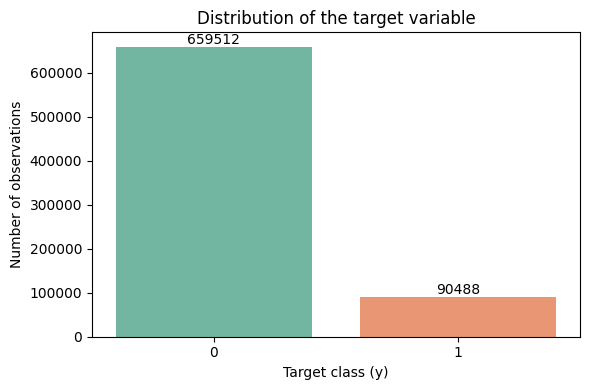

In [16]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x=y, hue=y, palette="Set2", legend=False)

plt.title("Distribution of the target variable")
plt.xlabel("Target class (y)")
plt.ylabel("Number of observations")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

In [17]:
majority_class = y.mode()[0]
baseline_accuracy = (y == majority_class).mean()

print("Majority class:", majority_class)
print(f"Naive baseline accuracy: {baseline_accuracy:.4f}")

Majority class: 0
Naive baseline accuracy: 0.8793


The target variable is imbalanced: class 0 represents approximately 88% of the observations, while class 1 represents approximately 12%. Consequently, a naive model that always predicts class 0 would already achieve an accuracy of around 88%. Accuracy alone is therefore insufficient for evaluating the models. Precision, recall, F1-score, ROC-AUC and the confusion matrix will also be considered, with particular attention paid to the model’s ability to identify class 1.

#### **Step 12 - Descriptive statistics for numerical variables**

In [18]:
numerical_summary = X[num_cols].describe().T

numerical_summary["median"] = X[num_cols].median()
numerical_summary["skewness"] = X[num_cols].skew()

numerical_summary

,count,mean,std,min,25%,50%,75%,max,median,skewness
age,750000.0,40.926395,10.098829,18.0,33.0,39.0,48.0,95.0,39.0,0.586137
balance,750000.0,1204.067397,2836.096759,-8019.0,0.0,634.0,1390.0,99717.0,634.0,12.304123
day,750000.0,16.117209,8.250832,1.0,9.0,17.0,21.0,31.0,17.0,0.054014
campaign,750000.0,2.577008,2.718514,1.0,1.0,2.0,3.0,63.0,2.0,4.810437
pdays,750000.0,22.412733,77.319998,-1.0,-1.0,-1.0,-1.0,871.0,-1.0,3.625049
previous,750000.0,0.298545,1.335926,0.0,0.0,0.0,0.0,200.0,0.0,13.749885


In [19]:
print("Distribution of previous:")
print(X["previous"].value_counts().sort_index().head(15))

print("\nMost frequent values of pdays:")
print(X["pdays"].value_counts().head(15))

Distribution of previous:
previous
0     672431
1      28342
2      20468
3      10326
4       6239
5       3882
6       2183
7       1730
8       1036
9        697
10       501
11       503
12       320
13       327
14       137
Name: count, dtype: int64

Most frequent values of pdays:
pdays
-1      672434
 182      2515
 92       2275
 183      2074
 181      1698
 91       1675
 370      1532
 184      1293
 350      1184
 364       942
 175       901
 94        891
 95        865
 343       854
 185       853
Name: count, dtype: int64


In [20]:
never_contacted_count = (X["pdays"] == -1).sum()
never_contacted_percentage = (X["pdays"] == -1).mean() * 100

print("Clients with pdays = -1:", never_contacted_count)
print(f"Percentage with pdays = -1: {never_contacted_percentage:.2f}%")

Clients with pdays = -1: 672434
Percentage with pdays = -1: 89.66%


The numerical variables have different distributions and scales. age and day have relatively limited ranges, whereas balance, campaign, pdays, and previous may be strongly skewed and contain extreme values. The value -1 in pdays is particularly important because it is a special code rather than a genuine negative number of days. It generally indicates that the client was not contacted during a previous campaign. Similarly, a value of 0 in previous indicates that no contacts were made before the current campaign. These special values will be preserved because they contain useful historical information.

#### **Step 13 — Visualize numerical distributions**

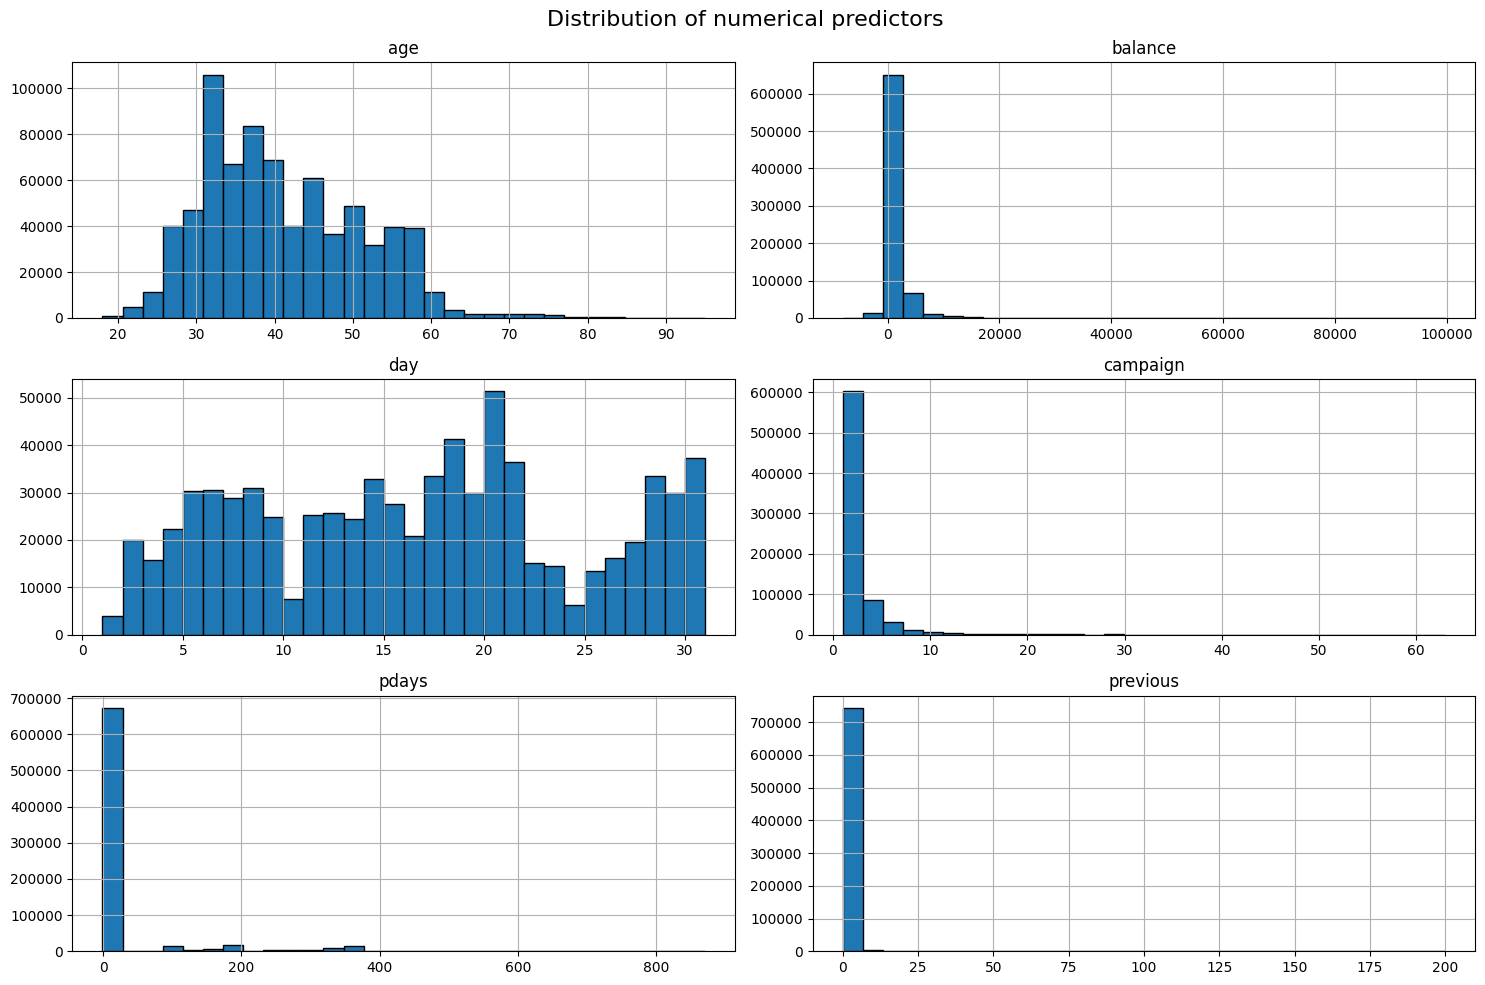

In [21]:
X[num_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of numerical predictors", fontsize=16)
plt.tight_layout()
plt.show()

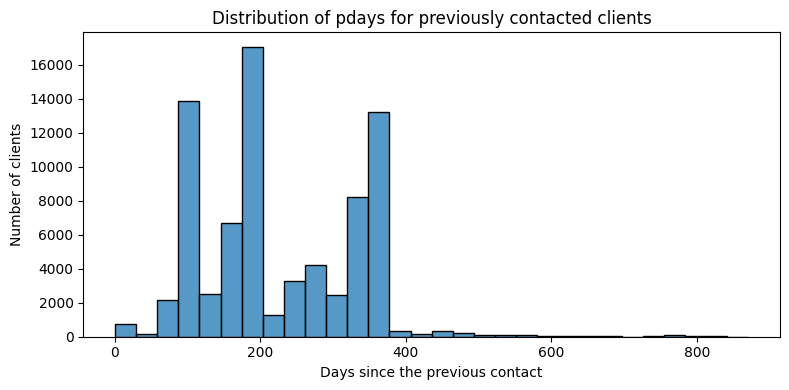

In [22]:
pdays_contacted = X.loc[X["pdays"] != -1, "pdays"]

plt.figure(figsize=(8, 4))
sns.histplot(pdays_contacted, bins=30)

plt.title("Distribution of pdays for previously contacted clients")
plt.xlabel("Days since the previous contact")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

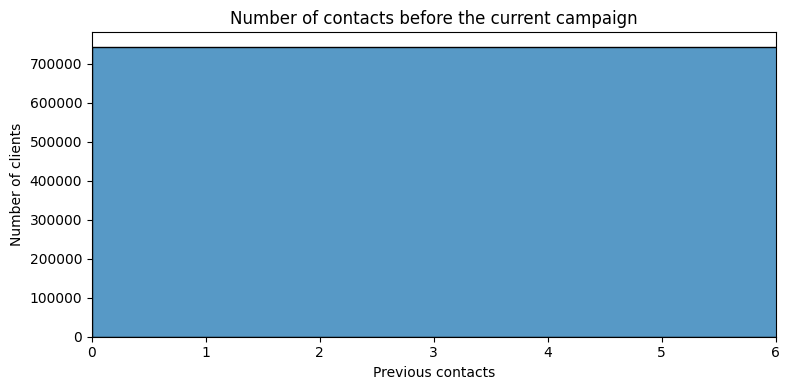

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(X["previous"], bins=30)

plt.title("Number of contacts before the current campaign")
plt.xlabel("Previous contacts")
plt.ylabel("Number of clients")
plt.xlim(0, X["previous"].quantile(0.99))
plt.tight_layout()
plt.show()

The histograms show that the numerical variables have heterogeneous distributions. balance, campaign, and previous are strongly right-skewed, with many small values and relatively few extreme observations. The distribution of pdays is dominated by the special value -1, representing clients who were not contacted in a previous campaign. When these clients are excluded from the visualization, the distribution shows the number of days elapsed since the previous contact. These historical variables may provide valuable information about the client’s past interactions with the bank.

#### **Step 14 — Analyse categorical variables**

In [24]:
for col in cat_cols:
    print(f"\n=== {col} ===")

    category_summary = pd.DataFrame({
        "Count": X[col].value_counts(),
        "Percentage": X[col].value_counts(normalize=True).mul(100).round(2)
    })

    print(category_summary)


=== job ===
                Count  Percentage
job                              
management     175541       23.41
blue-collar    170498       22.73
technician     138107       18.41
admin.          81492       10.87
services        64209        8.56
retired         35185        4.69
self-employed   19020        2.54
entrepreneur    17718        2.36
unemployed      17634        2.35
housemaid       15912        2.12
student         11767        1.57
unknown          2917        0.39

=== marital ===
           Count  Percentage
marital                     
married   480759       64.10
single    194834       25.98
divorced   74407        9.92

=== education ===
            Count  Percentage
education                    
secondary  401683       53.56
tertiary   227508       30.33
primary     99510       13.27
unknown     21299        2.84

=== default ===
          Count  Percentage
default                    
no       737151       98.29
yes       12849        1.71

=== housing ===
    

In [25]:
poutcome_summary = pd.DataFrame({
    "Count": X["poutcome"].value_counts(),
    "Percentage": X["poutcome"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
})

poutcome_summary

,Count,Percentage
poutcome,,
unknown,672450,89.66
failure,45115,6.02
success,17691,2.36
other,14744,1.97


In [26]:
previous_campaign_consistency = (
    train.groupby("poutcome")
    .agg(
        number_of_clients=("poutcome", "size"),
        median_previous_contacts=("previous", "median"),
        mean_previous_contacts=("previous", "mean"),
        percentage_pdays_minus_1=("pdays", lambda s: (s == -1).mean() * 100)
    )
    .round(2)
)

previous_campaign_consistency

,number_of_clients,median_previous_contacts,mean_previous_contacts,percentage_pdays_minus_1
poutcome,,,,
failure,45115,2.0,2.60,0.03
other,14744,2.0,3.63,0.02
success,17691,2.0,2.99,0.02
unknown,672450,0.0,0.00,99.99


The categorical variables have different numbers of categories and different levels of imbalance. Variables such as job contain many categories, whereas binary variables such as default, housing, and loan contain fewer categories. Several variables also contain the category unknown, particularly contact and poutcome. These values are preserved because unavailable information may itself be informative. The variable poutcome is especially important because it describes the outcome of the previous marketing campaign and is therefore one of the central historical variables in this analysis.
The consistency analysis confirms that the three previous-campaign variables are strongly related. For clients whose poutcome is failure, other, or success, the median number of previous contacts is 2, and almost none have pdays = -1. In contrast, clients with poutcome = "unknown" have no previous contacts on average, and 99.99% have pdays = -1. Therefore, the unknown category primarily represents the absence of a previous campaign interaction rather than an ordinary missing value. It should consequently be preserved as a meaningful category.

#### **Step 15 — Visualize categorical variables**

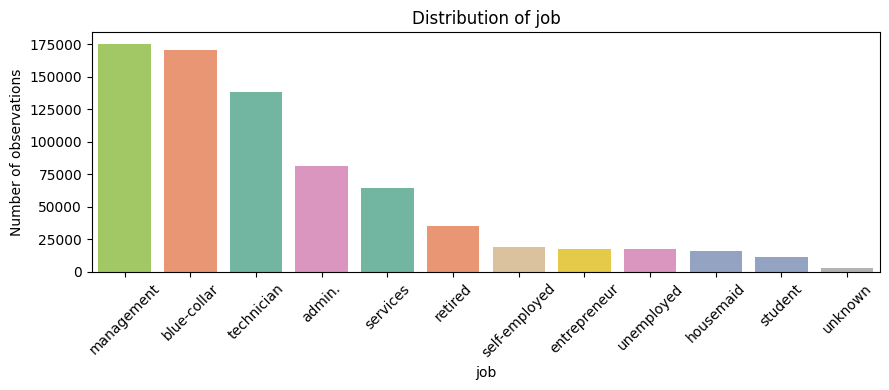

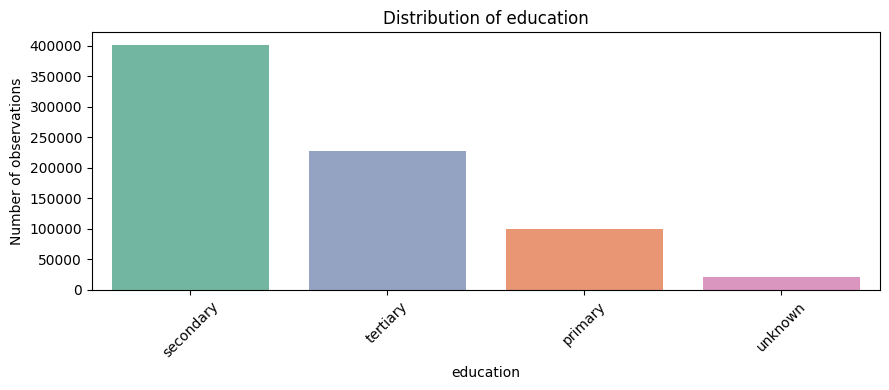

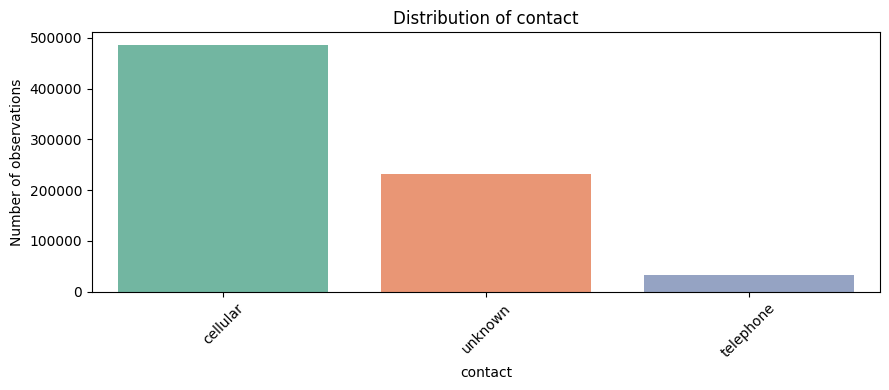

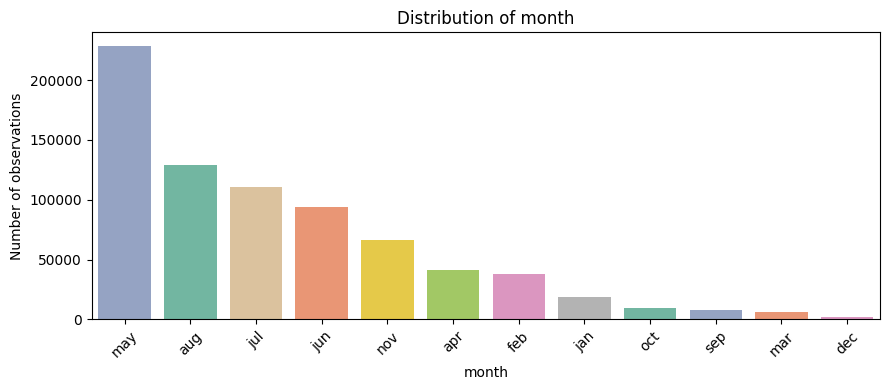

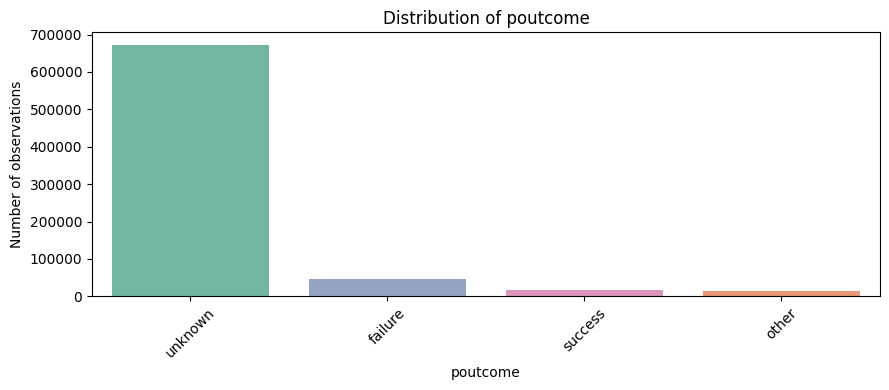

In [27]:
important_cat = ["job", "education", "contact", "month", "poutcome"]

for col in important_cat:
    plt.figure(figsize=(9, 4))

    order = X[col].value_counts().index

    sns.countplot(
        data=X,
        x=col,
        order=order,
        hue=col,
        palette="Set2",
        legend=False
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of observations")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

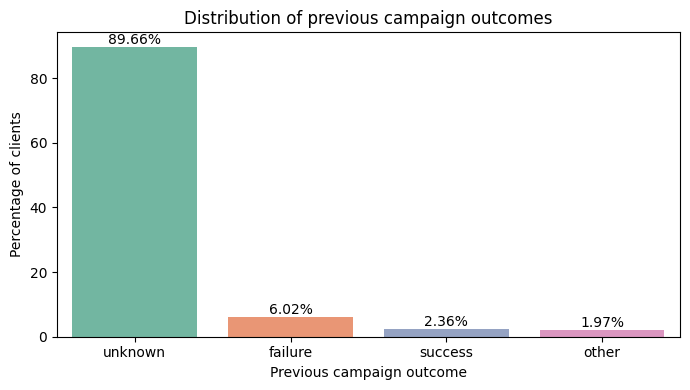

In [28]:
poutcome_percentages = (
    X["poutcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=poutcome_percentages.index,
    y=poutcome_percentages.values,
    hue=poutcome_percentages.index,
    palette="Set2",
    legend=False
)

plt.title("Distribution of previous campaign outcomes")
plt.xlabel("Previous campaign outcome")
plt.ylabel("Percentage of clients")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

The categorical distributions show that several variables are imbalanced. The job variable contains many professional categories, whereas education is concentrated around a smaller number of levels. The month variable shows that campaign activity is not distributed uniformly throughout the year. Most importantly, poutcome is largely dominated by the unknown category. Combined with the previous consistency analysis, this indicates that most clients were not contacted during an earlier campaign. The smaller success, failure, and other groups contain the available outcomes of previous marketing interactions.

#### **Step 16 — Study the relationship between numerical variables and the target**

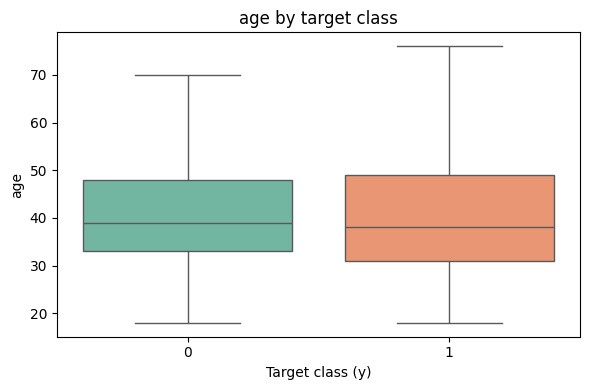

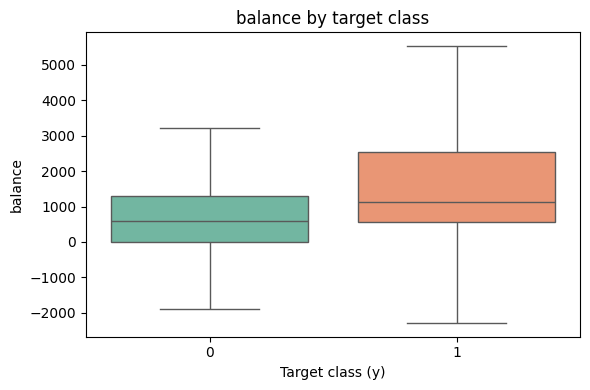

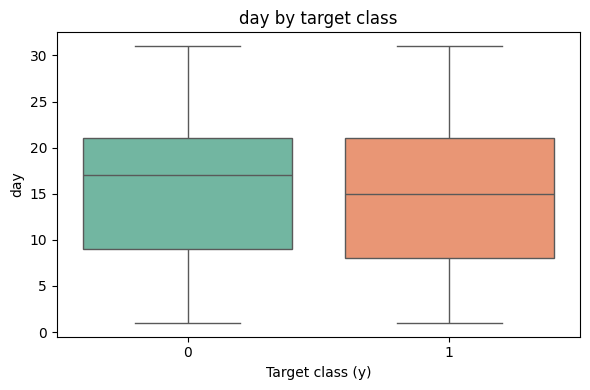

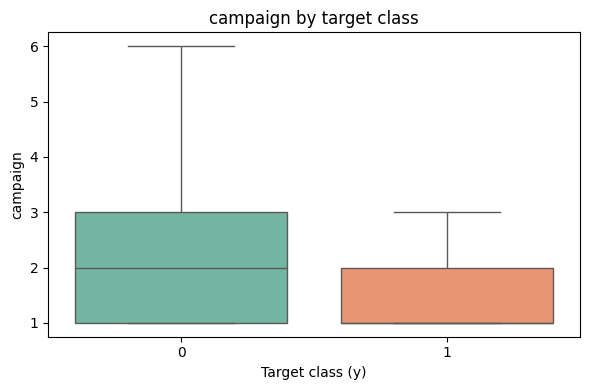

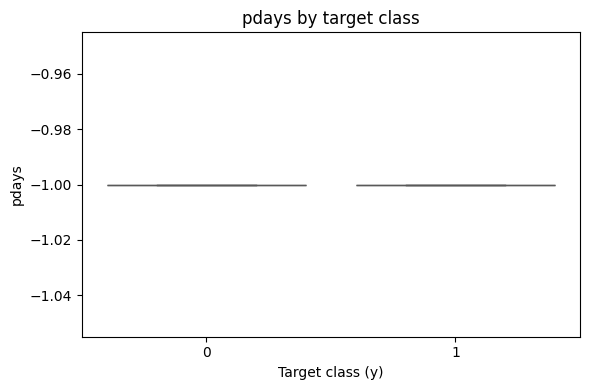

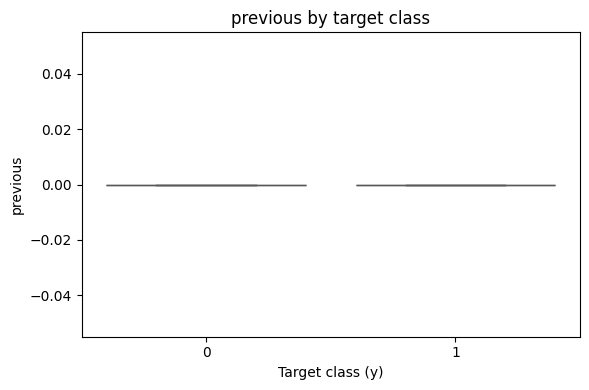

In [29]:
for col in num_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=train,
        x="y",
        y=col,
        hue="y",
        palette="Set2",
        legend=False,
        showfliers=False
    )

    plt.title(f"{col} by target class")
    plt.xlabel("Target class (y)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [30]:
numerical_target_summary = (
    train.groupby("y")[list(num_cols)]
    .agg(["mean", "median"])
    .round(2)
)

numerical_target_summary.T

y                      0        1
age      mean      40.89    41.19
         median    39.00    38.00
balance  mean    1075.36  2142.10
         median   584.00  1134.00
day      mean      16.27    15.01
         median    17.00    15.00
campaign mean       2.65     2.02
         median     2.00     1.00
pdays    mean      19.86    41.05
         median    -1.00    -1.00
previous mean       0.24     0.73
         median     0.00     0.00

In [31]:
previous_contact_analysis = train.assign(
    previously_contacted=np.where(train["pdays"] == -1, "No", "Yes")
)

previous_contact_target = (
    previous_contact_analysis
    .groupby("previously_contacted")["y"]
    .agg(
        number_of_clients="count",
        subscriptions="sum",
        subscription_rate="mean"
    )
)

previous_contact_target["subscription_rate"] *= 100
previous_contact_target.round(2)

,number_of_clients,subscriptions,subscription_rate
previously_contacted,,,
No,672434,68523,10.19
Yes,77566,21965,28.32


In [32]:
previous_contact_groups = pd.cut(
    train["previous"],
    bins=[-1, 0, 1, 2, 5, np.inf],
    labels=["0", "1", "2", "3–5", "More than 5"]
)

previous_count_target = (
    train.assign(previous_group=previous_contact_groups)
    .groupby("previous_group", observed=False)["y"]
    .agg(
        number_of_clients="count",
        subscription_rate="mean"
    )
)

previous_count_target["subscription_rate"] *= 100
previous_count_target.round(2)

,number_of_clients,subscription_rate
previous_group,,
0,672431,10.19
1,28342,25.74
2,20468,26.21
3–5,20447,32.21
More than 5,8312,32.75


The numerical variables show different relationships with the target. age has very similar distributions for the two target classes, suggesting little direct predictive power. In contrast, subscribed clients have a higher mean and median balance and require fewer contacts during the current campaign on average. Historical campaign information is particularly informative: previously contacted clients have a subscription rate of 28.32%, compared with only 10.19% for clients without previous contact. Moreover, the subscription rate increases from 10.19% for clients with no previous contacts to more than 32% for clients with three or more previous contacts. These results indicate that previous campaign history may provide important predictive information.

#### **Step 17 — Study the relationship between categorical variables and the target**

In [33]:
for col in cat_cols:
    category_target_summary = (
        train.groupby(col)["y"]
        .agg(
            number_of_clients="count",
            subscription_rate="mean"
        )
        .sort_values("subscription_rate", ascending=False)
    )

    category_target_summary["subscription_rate"] *= 100
    category_target_summary["subscription_rate"] = (
        category_target_summary["subscription_rate"].round(2)
    )

    print(f"\n=== {col} ===")
    print(category_target_summary)


=== job ===
               number_of_clients  subscription_rate
job                                                
student                    11767              34.08
retired                    35185              24.62
unemployed                 17634              17.98
management                175541              15.04
self-employed              19020              12.94
unknown                     2917              12.07
technician                138107              11.83
admin.                     81492              11.65
housemaid                  15912               8.47
services                   64209               8.27
entrepreneur               17718               8.14
blue-collar               170498               6.74

=== marital ===
          number_of_clients  subscription_rate
marital                                       
single               194834              17.05
divorced              74407              11.16
married              480759              10.19

=== ed

In [34]:
poutcome_target = (
    train.groupby("poutcome")["y"]
    .agg(
        number_of_clients="count",
        subscriptions="sum",
        subscription_rate="mean"
    )
    .sort_values("subscription_rate", ascending=False)
)

poutcome_target["subscription_rate"] *= 100
poutcome_target.round(2)

,number_of_clients,subscriptions,subscription_rate
poutcome,,,
success,17691,13516,76.40
other,14744,2460,16.68
failure,45115,5991,13.28
unknown,672450,68521,10.19


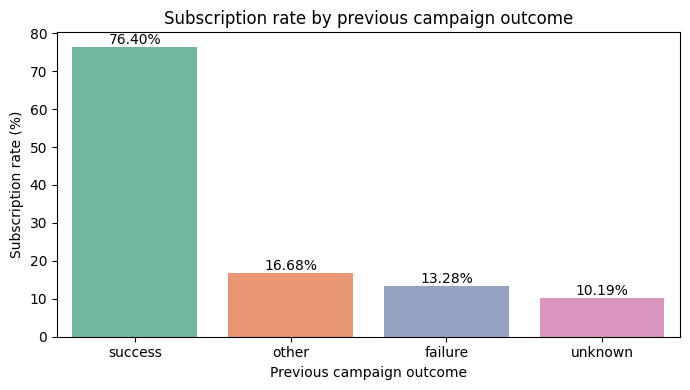

In [35]:
poutcome_plot = poutcome_target.reset_index()

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=poutcome_plot,
    x="poutcome",
    y="subscription_rate",
    hue="poutcome",
    palette="Set2",
    legend=False
)

plt.title("Subscription rate by previous campaign outcome")
plt.xlabel("Previous campaign outcome")
plt.ylabel("Subscription rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

The target distribution varies across several categorical variables, showing that these variables provide useful predictive information. The strongest historical relationship appears for poutcome. Clients whose previous campaign outcome was success have a substantially higher subscription rate than clients whose previous outcome was failure, other, or unknown. This suggests that a successful previous interaction is an important indicator of future subscription behaviour. The unknown category, which mainly represents clients without previous campaign history, has a lower subscription rate and remains informative rather than being treated as missing data.

### **Step 18 — Correlation analysis for numerical variables**

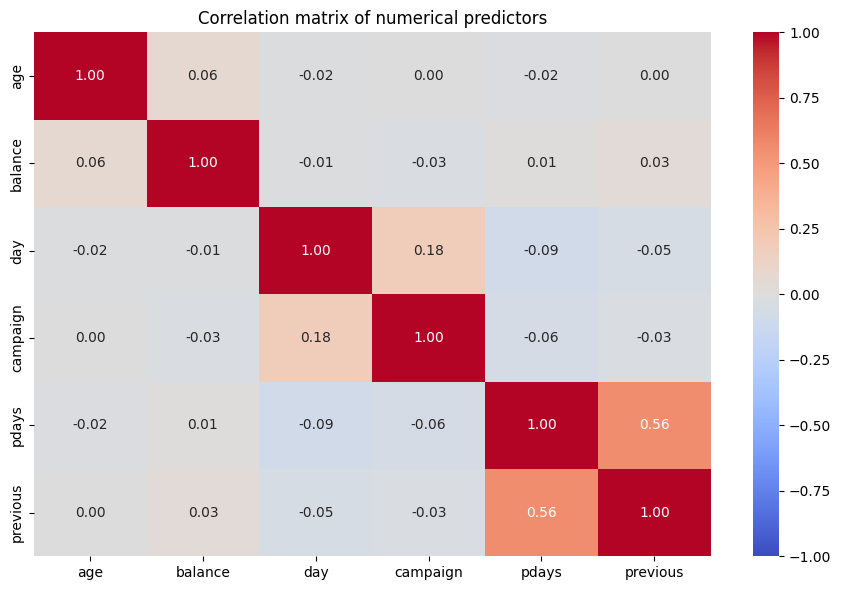

In [36]:
plt.figure(figsize=(9, 6))

correlation_matrix = X[num_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation matrix of numerical predictors")
plt.tight_layout()
plt.show()

In [37]:
numerical_target_correlations = (
    train[list(num_cols) + ["y"]]
    .corr()["y"]
    .drop("y")
    .sort_values(key=abs, ascending=False)
)

numerical_target_correlations

balance     0.122513
previous    0.119552
pdays       0.089277
campaign   -0.075829
day        -0.049625
age         0.009523
Name: y, dtype: float64

In [38]:
previously_contacted = train[train["pdays"] != -1]

previous_campaign_corr = previously_contacted[
    ["pdays", "previous", "y"]
].corr()

previous_campaign_corr

,pdays,previous,y
pdays,1.000000,-0.072396,-0.306827
previous,-0.072396,1.000000,0.024027
y,-0.306827,0.024027,1.000000


The numerical variables generally have weak linear relationships with the target. balance and previous have the strongest positive correlations in the complete dataset, although their values remain relatively low. campaign has a weak negative correlation, suggesting that clients requiring more contacts during the current campaign may be less likely to subscribe.

The interpretation of pdays changes when the special value -1 is excluded. In the complete dataset, pdays has a weak positive correlation with the target. However, among clients who were actually contacted during a previous campaign, its correlation becomes moderately negative (−0.307). This suggests that, for previously contacted clients, a more recent previous contact—represented by a smaller pdays value—is associated with a higher probability of subscription. The difference between the two results confirms that pdays = -1 represents a distinct group and should not be interpreted as an ordinary numerical value.

### **EDA summary**

The exploratory data analysis identified several important characteristics of the bank marketing dataset. After excluding the identifier id, the target y, and the leakage variable duration, the modeling dataset contains 15 predictors: 6 numerical variables and 9 categorical variables. duration was excluded because it is only known after the current call has occurred and therefore cannot be used for a realistic prediction made beforehand.

No technical missing values were detected in either the training or test predictors. However, several categorical variables contain the value unknown, particularly contact at 30.88% and poutcome at 89.66%. These values were preserved as meaningful categories rather than treated as ordinary missing values. The historical consistency analysis showed that poutcome="unknown" almost always corresponds to previous=0 and pdays=-1, confirming that it mainly represents clients who were not contacted during a previous campaign.

The target variable is imbalanced: 87.93% of observations belong to class 0 and 12.07% belong to class 1. A model always predicting class 0 would therefore achieve an accuracy of approximately 87.93%. Consequently, accuracy alone will not be sufficient for model evaluation. Precision, recall, F1-score, ROC-AUC, and the confusion matrix must also be considered.

The numerical variables have heterogeneous distributions. balance, campaign, pdays, and previous are strongly skewed and contain extreme values. The value pdays=-1 is not an ordinary numerical value but a special code indicating the absence of previous contact. Among clients who were previously contacted, pdays has a moderate negative correlation with the target (−0.307), suggesting that more recent previous contact is associated with a higher probability of subscription.

Previous campaign history appears particularly informative. Clients who were previously contacted have a subscription rate of 28.32%, compared with 10.19% among clients without previous contact. The subscription rate also increases with the number of previous contacts, reaching more than 32% for clients with at least three previous contacts.

Several categorical variables show substantial differences in subscription rates. The strongest historical relationship is observed for poutcome: clients whose previous campaign outcome was success have a subscription rate of 76.40%, compared with 16.68% for other, 13.28% for failure, and 10.19% for unknown. Variables such as month, contact, housing, loan, job, and education also show potentially useful differences between categories.

Most numerical predictors have weak linear correlations with the target, but this does not imply that they are uninformative. Nonlinear models may capture interactions and relationships that Pearson correlation does not detect. Overall, the EDA supports retaining the previous-campaign variables pdays, previous, and poutcome, while later creating an explicit indicator to distinguish clients with and without previous campaign contact.

### **Step 19 — Feature engineering before preprocessing**

In [39]:
# Create independent modeling copies
X_model = X.copy()
X_test_model = X_test.copy()

# Explicitly identify whether the client was previously contacted
X_model["previously_contacted"] = np.where(
    X_model["pdays"] == -1,
    "no",
    "yes"
)

X_test_model["previously_contacted"] = np.where(
    X_test_model["pdays"] == -1,
    "no",
    "yes"
)

# Convert the special pdays code into a missing value
# The pipeline will impute it later
X_model["pdays"] = X_model["pdays"].replace(-1, np.nan)
X_test_model["pdays"] = X_test_model["pdays"].replace(-1, np.nan)

In [40]:
print("Training shape:", X_model.shape)
print("Test shape:", X_test_model.shape)

print("\nPreviously contacted:")
print(X_model["previously_contacted"].value_counts())

print("\nMissing pdays after transformation:")
print(X_model["pdays"].isnull().sum())

print("\nFirst rows:")
display(
    X_model[
        ["pdays", "previous", "poutcome", "previously_contacted"]
    ].head(10)
)

Training shape: (750000, 16)
Test shape: (250000, 16)

Previously contacted:
previously_contacted
no     672434
yes     77566
Name: count, dtype: int64

Missing pdays after transformation:
672434

First rows:


,pdays,previous,poutcome,previously_contacted
0,NaN,0,unknown,no
1,NaN,0,unknown,no
2,NaN,0,unknown,no
3,NaN,0,unknown,no
4,NaN,0,unknown,no
5,NaN,0,unknown,no
6,NaN,0,unknown,no
7,NaN,0,unknown,no
8,NaN,0,unknown,no
9,NaN,0,unknown,no


A new categorical variable, previously_contacted, was created to distinguish clients with and without previous campaign interactions. The special value pdays=-1 was then converted to a missing value because it does not represent a genuine number of elapsed days. Missing pdays values will be imputed within the preprocessing pipeline, while previously_contacted preserves the information that no earlier contact occurred. This transformation is deterministic and uses no target information, so it does not create data leakage.

### **Step 20 — Redefine feature groups**

In [41]:
num_cols_model = X_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols_model = X_model.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical variables:", num_cols_model)
print("Categorical variables:", cat_cols_model)

print("\nNumber of numerical variables:", len(num_cols_model))
print("Number of categorical variables:", len(cat_cols_model))

Numerical variables: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'previously_contacted']

Number of numerical variables: 6
Number of categorical variables: 10


### **Step 21 — Create the training and validation sets**

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_model,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (600000, 16)
X_valid shape: (150000, 16)
y_train shape: (600000,)
y_valid shape: (150000,)


In [43]:
class_distribution = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).sort_index(),
    "Training set": y_train.value_counts(normalize=True).sort_index(),
    "Validation set": y_valid.value_counts(normalize=True).sort_index()
}).mul(100).round(2)

class_distribution

,Full dataset,Training set,Validation set
y,,,
0,87.93,87.94,87.93
1,12.07,12.06,12.07


### **Step 22 — Build the preprocessing pipelines**

We need different preprocessing for Logistic Regression and tree-based models.

#### **22-a — Numerical preprocessing for Logistic Regression**

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [45]:
# Create the numerical pipeline
numerical_pipeline_logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

This performs two operations:
SimpleImputer(strategy="median") replaces missing pdays values using the median calculated from the training data.
StandardScaler() standardizes every numerical variable: $$ z = \frac{x-\mu}{\sigma} $$

After scaling, each numerical variable is approximately centred around 0 with a standard deviation of 1.
Scaling is important for Logistic Regression because variables such as balance, age, and previous use very different numerical scales.

#### **22-b — Categorical preprocessing**

In [46]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

#### **22-c — Complete Logistic Regression preprocessor**

In [47]:
# The ColumnTransformer applies:
# Numerical transformations only to num_cols_model.
# Categorical transformations only to cat_cols_model.

preprocessor_logreg = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline_logreg,
            num_cols_model
        ),
        (
            "cat",
            categorical_pipeline,
            cat_cols_model
        )
    ]
)

preprocessor_logreg

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### **Step 23 — Preprocessing for tree-based models**

Random Forest and XGBoost do not require standardized numerical variables because they make decisions using thresholds, such as: balance <= 1000
<br>
Scaling does not change the order of the values, so it provides no important advantage for decision trees.


In [48]:
# Create a numerical pipeline without StandardScaler:
numerical_pipeline_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [49]:
# Then create the complete tree-model preprocessor :
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline_tree,
            num_cols_model
        ),
        (
            "cat",
            categorical_pipeline,
            cat_cols_model
        )
    ]
)

preprocessor_tree

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Two preprocessing pipelines were constructed. For Logistic Regression, missing numerical values are imputed using the training-set median and numerical variables are standardized. For Random Forest and XGBoost, numerical values are imputed but not standardized because tree-based models are insensitive to feature scale. In both cases, categorical variables are imputed using their most frequent category and transformed using one-hot encoding. All preprocessing operations will be fitted only on the training data through model pipelines, preventing data leakage.

### **Step 24 — Define a reusable evaluation function**

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [51]:
def evaluate_model(model_name, model, X_valid, y_valid):
    # Predicted classes using the default threshold of 0.5
    y_pred = model.predict(X_valid)

    # Predicted probability of class 1
    y_proba = model.predict_proba(X_valid)[:, 1]

    # Calculate metrics
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1-score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_proba),
        "PR-AUC": average_precision_score(y_valid, y_proba)
    }

    print(f"Evaluation of {model_name}\n")

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_valid, y_pred, digits=4))

    ConfusionMatrixDisplay.from_predictions(
        y_valid,
        y_pred,
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return results, y_pred, y_proba

Accuracy : Percentage of all correct predictions <br>
Precision : Among predicted subscribers, how many actually subscribed <br>
Recall : Among actual subscribers, how many the model detected <br>
F1-score : Balance between precision and recall <br>
ROC-AUC : Ability to rank positive observations above negative ones <br>
PR-AUC : Precision-recall performance, especially useful for imbalanced data <br>
<br>
Because only around 12% of observations belong to class 1, focus especially on: Recall, Precision, F1-score, PR-AUC and ROC-AUC

### **Step 25 — Build the baseline Logistic Regression**

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_logreg),

    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Raw data <br>
   ↓ <br>
Numerical imputation and scaling <br>
   ↓ <br>
Categorical imputation and one-hot encoding <br>
   ↓ <br>
Logistic Regression <br>
   ↓ <br>
Probability of subscription

### **Step 26 — Train the model**

In [53]:
logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### **Step 27 — Evaluate Logistic Regression**

Evaluation of Logistic Regression

Accuracy: 0.8918
Precision: 0.6837
Recall: 0.1923
F1-score: 0.3002
ROC-AUC: 0.7780
PR-AUC: 0.4399

Classification report:
              precision    recall  f1-score   support

           0     0.8991    0.9878    0.9414    131902
           1     0.6837    0.1923    0.3002     18098

    accuracy                         0.8918    150000
   macro avg     0.7914    0.5900    0.6208    150000
weighted avg     0.8731    0.8918    0.8640    150000



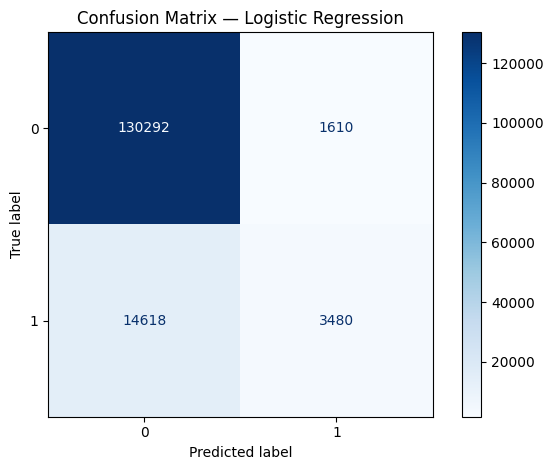

In [54]:
logreg_results, y_pred_logreg, y_proba_logreg = evaluate_model(
    model_name="Logistic Regression",
    model=logreg_model,
    X_valid=X_valid,
    y_valid=y_valid
)

In [55]:
baseline_results = pd.DataFrame([logreg_results])
baseline_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.891813,0.683694,0.192286,0.300155,0.778028,0.439928


### **Step 28 — Build the baseline Random Forest**

Random Forest combines many decision trees. Each tree is trained using: <br>
A random bootstrap sample of the training observations. <br>
A random subset of features at each split.
<br>
The final prediction is based on the votes of all trees. This reduces the instability and overfitting of a single decision tree.

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),

    ("classifier", RandomForestClassifier(
        n_estimators=100, # constructs 100 decision trees
        random_state=42, # makes the result reproducible
        n_jobs=-1 # utilize all available CPU cores
        # Other parameters remain at their default values because this is an untuned baseline
    ))
])

rf_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### **Step 29 — Train Random Forest**

In [57]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### **Step 30 — Evaluate Random Forest**

Evaluation of Random Forest

Accuracy: 0.8928
Precision: 0.6050
Recall: 0.3216
F1-score: 0.4199
ROC-AUC: 0.8127
PR-AUC: 0.4692

Classification report:
              precision    recall  f1-score   support

           0     0.9125    0.9712    0.9410    131902
           1     0.6050    0.3216    0.4199     18098

    accuracy                         0.8928    150000
   macro avg     0.7588    0.6464    0.6804    150000
weighted avg     0.8754    0.8928    0.8781    150000



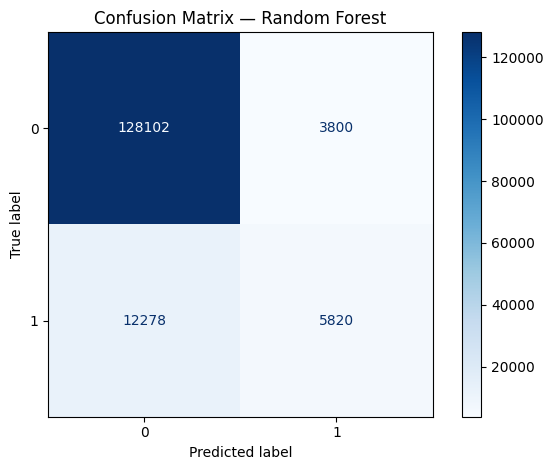

In [58]:
rf_results, y_pred_rf, y_proba_rf = evaluate_model(
    model_name="Random Forest",
    model=rf_model,
    X_valid=X_valid,
    y_valid=y_valid
)

In [59]:
baseline_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([rf_results])
    ],
    ignore_index=True
)

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.8918,0.6837,0.1923,0.3002,0.7780,0.4399
1,Random Forest,0.8928,0.6050,0.3216,0.4199,0.8127,0.4692


Random Forest outperforms Logistic Regression on accuracy, recall, F1-score, ROC-AUC, and PR-AUC. Its recall increases from 19.23% to 32.16%, indicating that it detects a substantially larger proportion of actual subscribers. However, its precision decreases from 68.37% to 60.50%, meaning that more of its positive predictions are false positives. Overall, the improved F1-score and ranking metrics suggest that Random Forest captures useful nonlinear relationships that Logistic Regression cannot fully represent.

### **Step 31 — Build the baseline XGBoost model**

XGBoost constructs trees sequentially. Each new tree attempts to correct errors made by the existing collection of trees.

In [60]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),

    ("classifier", XGBClassifier(
        n_estimators=100, # number of sequential trees
        max_depth=6, # maximum depth of each tree
        learning_rate=0.1, # contribution of each new tree
        subsample=0.8, # fraction of samples used for training each tree - each tree uses 80% of training observations
        colsample_bytree=0.8, # each tree uses 80% of features
        objective="binary:logistic", # returns probabilities for binary classification
        eval_metric="logloss", # evaluates the model using log loss - internal training evaluation metric
        tree_method="hist", # use histogram-based algorithm for faster training on large datasets
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### **Step 32 — Train XGBoost**

In [61]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### **Step 33 — Evaluate XGBoost**

Evaluation of XGBoost

Accuracy: 0.8989
Precision: 0.6890
Recall: 0.2959
F1-score: 0.4140
ROC-AUC: 0.8425
PR-AUC: 0.5234

Classification report:
              precision    recall  f1-score   support

           0     0.9104    0.9817    0.9447    131902
           1     0.6890    0.2959    0.4140     18098

    accuracy                         0.8989    150000
   macro avg     0.7997    0.6388    0.6794    150000
weighted avg     0.8837    0.8989    0.8807    150000



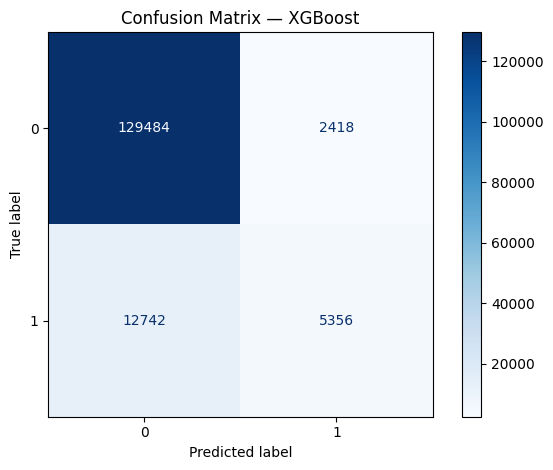

In [62]:
xgb_results, y_pred_xgb, y_proba_xgb = evaluate_model(
    model_name="XGBoost",
    model=xgb_model,
    X_valid=X_valid,
    y_valid=y_valid
)

In [63]:
baseline_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([xgb_results])
    ],
    ignore_index=True
)

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.8918,0.6837,0.1923,0.3002,0.7780,0.4399
1,Random Forest,0.8928,0.6050,0.3216,0.4199,0.8127,0.4692
2,XGBoost,0.8989,0.6890,0.2959,0.4140,0.8425,0.5234


At this point, all three models are being evaluated: <br>
- On the same validation observations. <br>
- Without duration. <br>
- With the same engineered historical information. <br>
- Using the default probability threshold of 0.5. <br>
- Before class balancing, threshold adjustment, or hyperparameter tuning.

Among the three baseline models, XGBoost achieves the best accuracy, precision, ROC-AUC, and PR-AUC. Its PR-AUC of 0.5234 is particularly encouraging given that only approximately 12% of observations belong to class 1. Random Forest has the highest recall and a slightly higher F1-score at the default threshold of 0.5, meaning that it currently identifies more actual subscribers. Logistic Regression provides the weakest overall performance, suggesting that the relationships between the predictors and target are not entirely linear. XGBoost appears to be the strongest probability-ranking model, while its final classification performance may improve after hyperparameter and threshold tuning.

### **Step 34 — Compare ROC curves**

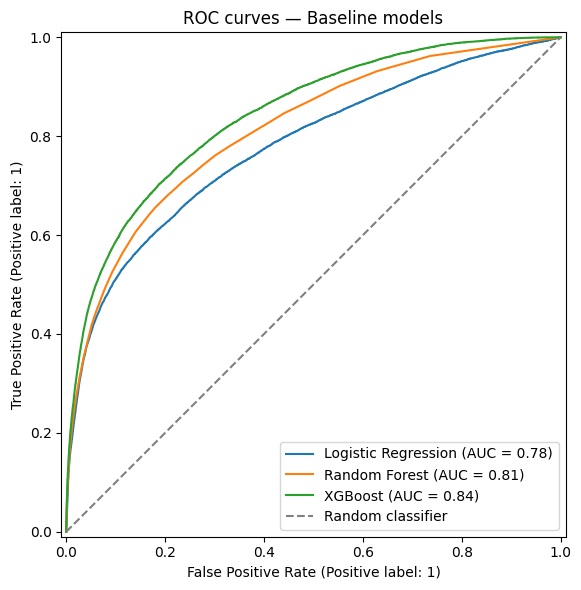

In [64]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_valid,
    y_proba_logreg,
    name="Logistic Regression",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_valid,
    y_proba_rf,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_valid,
    y_proba_xgb,
    name="XGBoost",
    ax=plt.gca()
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

plt.title("ROC curves — Baseline models")
plt.legend()
plt.tight_layout()
plt.show()

### **Step 35 — Compare precision-recall curves**

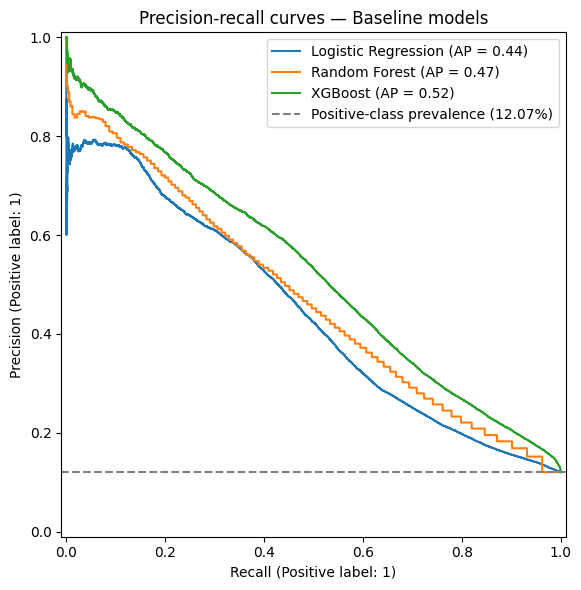

In [65]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_proba_logreg,
    name="Logistic Regression",
    ax=plt.gca()
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_proba_rf,
    name="Random Forest",
    ax=plt.gca()
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_proba_xgb,
    name="XGBoost",
    ax=plt.gca()
)

plt.axhline(
    y=y_valid.mean(),
    linestyle="--",
    color="grey",
    label=f"Positive-class prevalence ({y_valid.mean():.2%})"
)

plt.title("Precision-recall curves — Baseline models")
plt.legend()
plt.tight_layout()
plt.show()

The ROC and precision-recall curves confirm that XGBoost provides the best discrimination across a wide range of classification thresholds. Its ROC curve is consistently above those of Random Forest and Logistic Regression, and its precision-recall curve maintains higher precision for most recall levels. The difference is especially visible in the PR-AUC values: XGBoost reaches approximately 0.52, compared with 0.47 for Random Forest and 0.44 for Logistic Regression. All three models substantially outperform the positive-class prevalence baseline of 12.07%, but XGBoost currently offers the strongest probability ranking.

### **Step 36 — Define the tuning strategy**

In [66]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

### **Step 37 — Fine-tune Logistic Regression**

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

C is the inverse of regularization strength: <br>
- Small C → stronger regularization → simpler coefficients. <br>
- Large C → weaker regularization → more flexible coefficients. <br>

Regularization reduces the risk of overfitting

class_weight <br>
With:<br>
class_weight=None <br>
each training observation has the same importance. <br>

With: <br>
class_weight="balanced" <br>
scikit-learn automatically gives greater importance to the minority class: $$ w_c = \frac{n}{k \times n_c} $$

where:<br>
\(n\) is the total number of observations. <br>
\(k\) is the number of classes. <br>
\(n_c\) is the number of observations in class \(c\). <br>

This will usually increase recall, but it may reduce precision

### **Step 38 — Run cross-validated tuning**

In [68]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Evaluation metric used to select the best parameters
scoring_metric = "average_precision"

# Three-fold stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Logistic Regression search space
param_grid_logreg = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

In [69]:
grid_logreg = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid_logreg,
    scoring=scoring_metric,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_logreg.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

### **Step 39 — Inspect the tuning results**

In [70]:
print("Best parameters:")
print(grid_logreg.best_params_)

print("\nBest mean cross-validation PR-AUC:")
print(round(grid_logreg.best_score_, 4))

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None}

Best mean cross-validation PR-AUC:
0.4442


In [71]:
logreg_cv_results = pd.DataFrame(
    grid_logreg.cv_results_
)[[
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

logreg_cv_results

,param_classifier__C,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score
6,10.00,None,0.444500,0.444205,0.002445,1
4,1.00,None,0.444457,0.444170,0.002458,2
2,0.10,None,0.444419,0.444135,0.002469,3
0,0.01,None,0.443745,0.443511,0.002410,4
7,10.00,balanced,0.430717,0.430486,0.002068,5
5,1.00,balanced,0.430578,0.430319,0.002063,6
3,0.10,balanced,0.430518,0.430274,0.002018,7
1,0.01,balanced,0.429549,0.429321,0.001917,8


### **Step 40 — Evaluate the tuned Logistic Regression**

In [72]:
best_logreg_model = grid_logreg.best_estimator_

Evaluation of Tuned Logistic Regression

Accuracy: 0.8918
Precision: 0.6835
Recall: 0.1926
F1-score: 0.3005
ROC-AUC: 0.7780
PR-AUC: 0.4400

Classification report:
              precision    recall  f1-score   support

           0     0.8992    0.9878    0.9414    131902
           1     0.6835    0.1926    0.3005     18098

    accuracy                         0.8918    150000
   macro avg     0.7913    0.5902    0.6209    150000
weighted avg     0.8731    0.8918    0.8640    150000



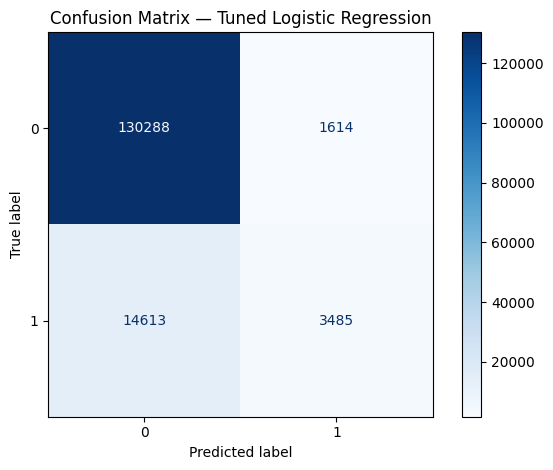

In [73]:
tuned_logreg_results, y_pred_logreg_tuned, y_proba_logreg_tuned = (
    evaluate_model(
        model_name="Tuned Logistic Regression",
        model=best_logreg_model,
        X_valid=X_valid,
        y_valid=y_valid
    )
)

In [74]:
logreg_comparison = pd.DataFrame([
    logreg_results,
    tuned_logreg_results
])

logreg_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.8918,0.6837,0.1923,0.3002,0.778,0.4399
1,Tuned Logistic Regression,0.8918,0.6835,0.1926,0.3005,0.778,0.4400


### **Step 41 — Tune the Random Forest**

Random Forest has more hyperparameters than Logistic Regression, so we use RandomizedSearchCV instead of testing every possible combination. The optimization metric remains PR-AUC, because the target is imbalanced.

#### **41.1 Create the search space**

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

# Copy the baseline pipeline
rf_tuning_model = clone(rf_model)

# Avoid nested parallel processing
rf_tuning_model.set_params(classifier__n_jobs=1)

param_distributions_rf = {
    "classifier__n_estimators": [200, 400], # number of trees in the forest
    "classifier__max_depth": [None, 10, 20], # maximum depth of each tree
    "classifier__min_samples_split": [2, 10, 20], # minimum number of samples required to split an internal node
    "classifier__min_samples_leaf": [1, 5, 10], # minimum number of samples required to be at a leaf node
    "classifier__max_features": ["sqrt", 0.5], # number of features to consider when looking for the best split
    "classifier__class_weight": [None, "balanced_subsample"] # whether the minority class receives additional importance
}

#### **41.2 Configure and run the randomized search**

In [76]:
random_rf = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=param_distributions_rf,
    n_iter=8,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=2,
    return_train_score=True
)

random_rf.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced_subsample'], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 0.5], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Gui

Due to the size of the dataset and the computational cost of Random Forest, a randomized search with eight parameter combinations and three-fold stratified cross-validation was used. This provides a practical balance between exploring the hyperparameter space and maintaining reasonable computational requirements. Average precision was selected as the optimization metric because the target variable is imbalanced. <br>
This performs: $$ 8\text{ combinations} \times 3\text{ folds}=24\text{ model fits} $$

#### **41.3 Display the best result**

In [77]:
print("Best Random Forest parameters:")
print(random_rf.best_params_)

print("\nBest cross-validation PR-AUC:")
print(round(random_rf.best_score_, 4))

Best Random Forest parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 0.5, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced_subsample'}

Best cross-validation PR-AUC:
0.5248


### **Step 42 — Check the overfitting gap**

In [78]:
best_rf_index = random_rf.best_index_

rf_cv_check = pd.DataFrame({
    "Score": [
        random_rf.cv_results_["mean_train_score"][best_rf_index],
        random_rf.cv_results_["mean_test_score"][best_rf_index],
        random_rf.cv_results_["std_test_score"][best_rf_index]
    ]
}, index=[
    "Mean training PR-AUC",
    "Mean cross-validation PR-AUC",
    "Cross-validation standard deviation"
])

rf_cv_check.round(4)

,Score
Mean training PR-AUC,0.7253
Mean cross-validation PR-AUC,0.5248
Cross-validation standard deviation,0.0007


### **Step 43 — Evaluate the tuned Random Forest**

Evaluation of Tuned Random Forest

Accuracy: 0.8583
Precision: 0.4363
Recall: 0.5972
F1-score: 0.5042
ROC-AUC: 0.8417
PR-AUC: 0.5242

Classification report:
              precision    recall  f1-score   support

           0     0.9418    0.8941    0.9173    131902
           1     0.4363    0.5972    0.5042     18098

    accuracy                         0.8583    150000
   macro avg     0.6890    0.7457    0.7108    150000
weighted avg     0.8808    0.8583    0.8675    150000



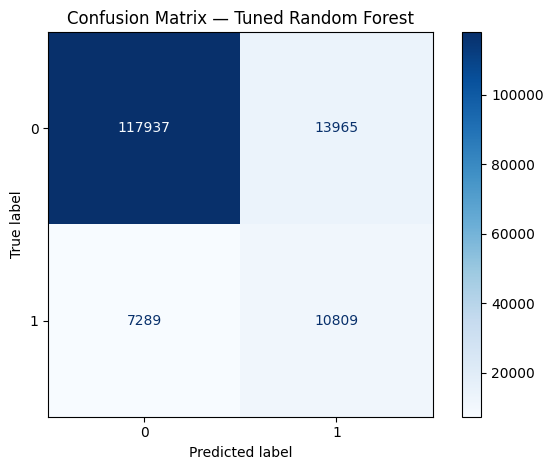

({'Model': 'Tuned Random Forest',
  'Accuracy': 0.8583066666666667,
  'Precision': 0.4363041898764834,
  'Recall': 0.5972483147309094,
  'F1-score': 0.504245194999067,
  'ROC-AUC': 0.8416892126261526,
  'PR-AUC': 0.524176943316147},
 array([0, 0, 0, ..., 0, 0, 0], shape=(150000,)),
 array([0.01663765, 0.13611822, 0.17594216, ..., 0.2829054 , 0.0644889 ,
        0.18705039], shape=(150000,)))

In [79]:
best_rf = random_rf.best_estimator_

tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    best_rf,
    X_valid,
    y_valid
)

tuned_rf_results

### **Step 44 — Prepare XGBoost tuning**

In [80]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

xgb_tuning_model = clone(xgb_model)

param_distributions_xgb = {
    "classifier__n_estimators": [200, 400, 600],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0],
    "classifier__min_child_weight": [1, 5, 10],
    "classifier__reg_lambda": [1, 5, 10]
}

In [81]:
xgb_tuning_model.set_params(
    classifier__tree_method="hist",
    classifier__device="cpu",
    classifier__n_jobs=1
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [82]:
random_xgb = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_distributions_xgb,
    n_iter=10,
    scoring="average_precision",
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

random_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=600, classifier__reg_lambda=5, classifier__subsample=1.0; total time=  24.4s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=600, classifier__reg_lambda=5, classifier__subsample=1.0; total time=  19.8s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.03, classifier__max_depth=5, classifier__min_child_weight=5, classifier__n_estimators=600, classifier__reg_lambda=5, classifier__subsample=1.0; total time=  19.3s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=3, classifier__min_child_weight=10, classifier__n_estimators=600, classifier__reg_lambda=10, classifier__subsample=0.8; total time=  25.9s
[C

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` 

### **Step 45 — Inspect the tuning results**

In [83]:
print("Best XGBoost parameters:")
print(random_xgb.best_params_)

print("\nBest cross-validation PR-AUC:")
print(round(random_xgb.best_score_, 4))

Best XGBoost parameters:
{'classifier__subsample': 0.7, 'classifier__reg_lambda': 1, 'classifier__n_estimators': 400, 'classifier__min_child_weight': 10, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1.0}

Best cross-validation PR-AUC:
0.5405


In [84]:
best_xgb_index = random_xgb.best_index_

xgb_cv_check = pd.DataFrame({
    "Score": [
        random_xgb.cv_results_["mean_train_score"][best_xgb_index],
        random_xgb.cv_results_["mean_test_score"][best_xgb_index],
        random_xgb.cv_results_["std_test_score"][best_xgb_index]
    ]
}, index=[
    "Mean training PR-AUC",
    "Mean cross-validation PR-AUC",
    "Cross-validation standard deviation"
])

xgb_cv_check.round(4)

,Score
Mean training PR-AUC,0.6047
Mean cross-validation PR-AUC,0.5405
Cross-validation standard deviation,0.0029


### **Step 46 — Evaluate tuned XGBoost**

In [85]:
best_xgb = random_xgb.best_estimator_

best_xgb.set_params(
    classifier__device="cpu"
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Evaluation of Tuned XGBoost

Accuracy: 0.9007
Precision: 0.6795
Recall: 0.3353
F1-score: 0.4490
ROC-AUC: 0.8527
PR-AUC: 0.5390

Classification report:
              precision    recall  f1-score   support

           0     0.9147    0.9783    0.9454    131902
           1     0.6795    0.3353    0.4490     18098

    accuracy                         0.9007    150000
   macro avg     0.7971    0.6568    0.6972    150000
weighted avg     0.8863    0.9007    0.8855    150000



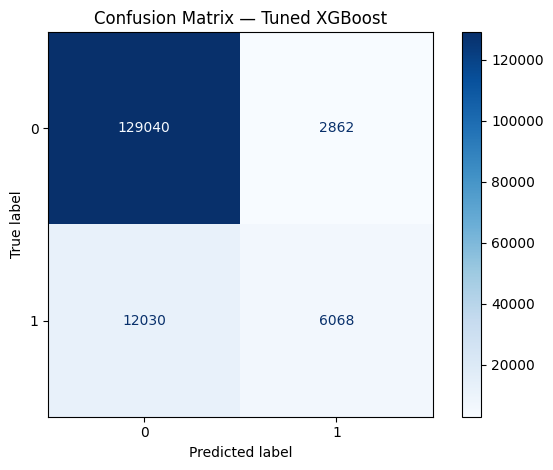

({'Model': 'Tuned XGBoost',
  'Accuracy': 0.90072,
  'Precision': 0.6795072788353863,
  'Recall': 0.33528566692452205,
  'F1-score': 0.4490158354299245,
  'ROC-AUC': 0.8526533405982823,
  'PR-AUC': 0.5390141404519896},
 array([0, 0, 0, ..., 0, 0, 0], shape=(150000,)),
 array([0.00277112, 0.05436022, 0.05027211, ..., 0.00839544, 0.00703696,
        0.0149007 ], shape=(150000,), dtype=float32))

In [86]:
tuned_xgb_results = evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_valid,
    y_valid
)

tuned_xgb_results

In [87]:
tuned_xgb_metrics, y_pred_xgb_tuned, y_prob_xgb_tuned = tuned_xgb_results

pd.DataFrame([tuned_xgb_metrics]).round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.9007,0.6795,0.3353,0.449,0.8527,0.539


### **Step 47 — Select a threshold using out-of-fold predictions**

In [88]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

oof_xgb_prob = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=cv_strategy,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [89]:
precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train,
    oof_xgb_prob
)

f1_oof = (
    2 * precision_oof[:-1] * recall_oof[:-1]
    / (precision_oof[:-1] + recall_oof[:-1] + 1e-10)
)

best_threshold_index = np.argmax(f1_oof)
best_threshold = thresholds_oof[best_threshold_index]

threshold_summary = pd.Series({
    "Selected threshold": best_threshold,
    "OOF precision": precision_oof[best_threshold_index],
    "OOF recall": recall_oof[best_threshold_index],
    "OOF F1-score": f1_oof[best_threshold_index]
})

threshold_summary.round(4)

Selected threshold    0.2453
OOF precision         0.5140
OOF recall            0.5473
OOF F1-score          0.5302
dtype: float64

### **Step 48 — Evaluate the selected threshold on validation data**

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_xgb_threshold = (
    y_prob_xgb_tuned >= best_threshold
).astype(int)

threshold_xgb_metrics = {
    "Model": "Tuned XGBoost — selected threshold",
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_valid, y_pred_xgb_threshold),
    "Precision": precision_score(y_valid, y_pred_xgb_threshold),
    "Recall": recall_score(y_valid, y_pred_xgb_threshold),
    "F1-score": f1_score(y_valid, y_pred_xgb_threshold),
    "ROC-AUC": roc_auc_score(y_valid, y_prob_xgb_tuned),
    "PR-AUC": average_precision_score(y_valid, y_prob_xgb_tuned)
}

pd.DataFrame([threshold_xgb_metrics]).round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Tuned XGBoost — selected threshold,0.2453,0.8828,0.5134,0.5415,0.5271,0.8527,0.539


In [91]:
print(
    classification_report(
        y_valid,
        y_pred_xgb_threshold,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9366    0.9296    0.9331    131902
           1     0.5134    0.5415    0.5271     18098

    accuracy                         0.8828    150000
   macro avg     0.7250    0.7355    0.7301    150000
weighted avg     0.8856    0.8828    0.8841    150000



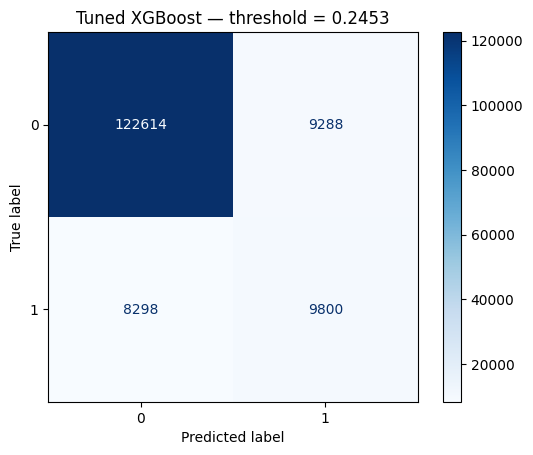

In [92]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred_xgb_threshold,
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Tuned XGBoost — threshold = {best_threshold:.4f}"
)
plt.show()

In [93]:
threshold_comparison = pd.DataFrame([
    {
        **tuned_xgb_metrics,
        "Threshold": 0.5
    },
    threshold_xgb_metrics
])

threshold_comparison[
    [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ]
].round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.5000,0.9007,0.6795,0.3353,0.4490,0.8527,0.539
1,Tuned XGBoost — selected threshold,0.2453,0.8828,0.5134,0.5415,0.5271,0.8527,0.539


### **Step 49 — Interpret feature importance**

In [94]:
feature_names = (
    best_xgb
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": (
        best_xgb
        .named_steps["classifier"]
        .feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
48,cat__poutcome_success,0.328892
33,cat__contact_unknown,0.095720
41,cat__month_mar,0.054155
49,cat__poutcome_unknown,0.052301
50,cat__previously_contacted_no,0.036652
31,cat__contact_cellular,0.034497
27,cat__housing_no,0.034184
34,cat__month_apr,0.032801
44,cat__month_oct,0.027842
40,cat__month_jun,0.026315


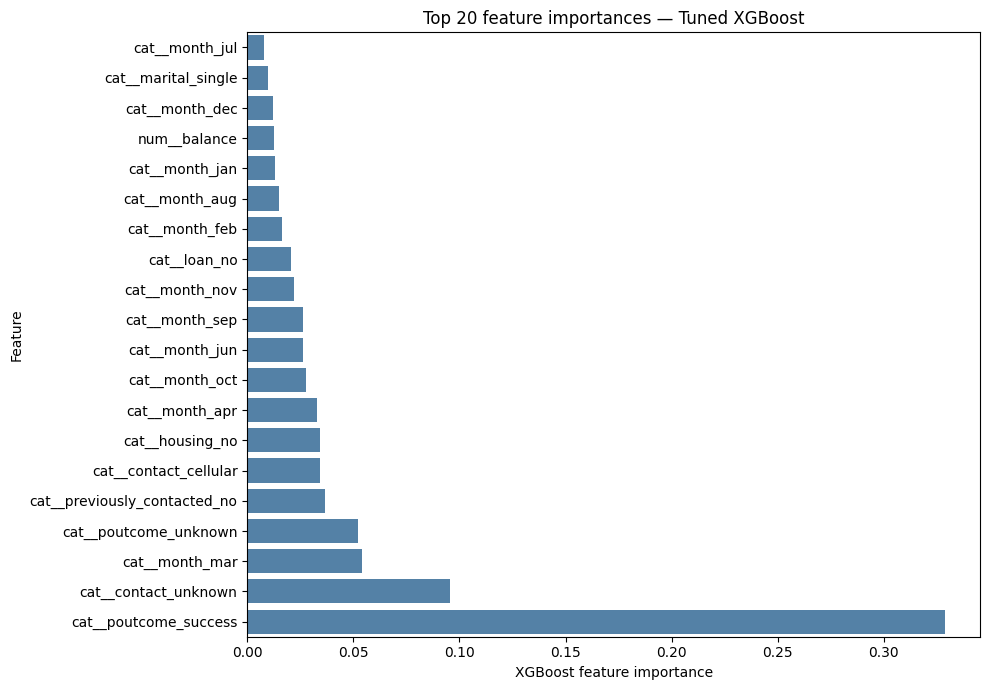

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 20 feature importances — Tuned XGBoost")
plt.xlabel("XGBoost feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature-importance interpretation

Previous campaign information was the most influential source of information
for the tuned XGBoost model. In particular, a successful outcome in the
previous campaign had substantially greater importance than any other
individual feature.

Contact-channel information and the month of contact were also important,
suggesting that campaign timing and communication strategy affect the
probability of a positive response. Features describing the absence of a
previous contact or an unknown previous outcome were influential as well.

Customer financial and demographic characteristics, such as balance, housing
loan status and marital status, contributed to the predictions but were less
important than previous campaign and contact-related information.

These feature-importance values indicate how strongly features were used by
the model. They do not show whether a feature increases or decreases the
predicted probability, and they should not be interpreted as causal effects.

### **Step 50 — Original-feature permutation importance**

In [96]:
from sklearn.inspection import permutation_importance

# Use a representative sample to keep computation reasonable
X_importance = X_valid.sample(
    n=min(20_000, len(X_valid)),
    random_state=42
)

y_importance = y_valid.loc[X_importance.index]

permutation_results = permutation_importance(
    best_xgb,
    X_importance,
    y_importance,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=1
)

permutation_df = pd.DataFrame({
    "Feature": X_importance.columns,
    "Importance": permutation_results.importances_mean,
    "Standard deviation": permutation_results.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

permutation_df.round(4)

,Feature,Importance,Standard deviation
10,month,0.1208,0.0008
8,contact,0.1003,0.0048
5,balance,0.0928,0.0043
9,day,0.0898,0.0014
14,poutcome,0.0835,0.0026
6,housing,0.0268,0.0012
12,pdays,0.0202,0.0002
11,campaign,0.0170,0.0017
0,age,0.0150,0.0003
7,loan,0.0112,0.0006


### Permutation-importance interpretation

Permutation importance identified the contact month, contact channel, customer
balance, contact day and previous campaign outcome as the most influential
original predictors.

Campaign timing therefore appears to play an important role in customer
response. However, the importance of month and day may also reflect seasonal
or operational patterns specific to the dataset, so their performance should
be monitored if the model is applied to future campaigns.

The previous campaign variables are correlated because `pdays`, `previous`,
`poutcome` and `previously_contacted` describe related aspects of historical
contact. Consequently, permutation importance may distribute their predictive
contribution across several variables.

The `default` feature produced approximately zero importance, suggesting that
it contributed little additional predictive information.

### **Step 51 — Error analysis**

In [97]:
error_analysis = X_valid.copy()

error_analysis["actual"] = y_valid
error_analysis["predicted"] = y_pred_xgb_threshold
error_analysis["probability"] = y_prob_xgb_tuned

error_analysis["prediction_type"] = np.select(
    [
        (error_analysis["actual"] == 1)
        & (error_analysis["predicted"] == 1),

        (error_analysis["actual"] == 0)
        & (error_analysis["predicted"] == 0),

        (error_analysis["actual"] == 0)
        & (error_analysis["predicted"] == 1),

        (error_analysis["actual"] == 1)
        & (error_analysis["predicted"] == 0)
    ],
    [
        "True positive",
        "True negative",
        "False positive",
        "False negative"
    ],
    default="Unknown"
)

error_analysis["prediction_type"].value_counts()

prediction_type
True negative     122614
True positive       9800
False positive      9288
False negative      8298
Name: count, dtype: int64

In [98]:
numerical_error_summary = (
    error_analysis
    .groupby("prediction_type")[num_cols_model]
    .median()
    .round(2)
)

numerical_error_summary

,age,balance,day,campaign,pdays,previous
prediction_type,,,,,,
False negative,38.0,890.0,16.0,2.0,268.0,0.0
False positive,37.0,1388.0,13.0,1.0,149.0,0.0
True negative,39.0,556.0,17.0,2.0,272.0,0.0
True positive,37.0,1429.0,13.0,1.0,155.0,0.0


In [99]:
contact_history_summary = (
    error_analysis
    .groupby("prediction_type")
    .agg(
        number_of_clients=("actual", "size"),
        positive_rate=("actual", "mean"),
        median_balance=("balance", "median"),
        median_campaign_contacts=("campaign", "median"),
        previously_contacted_rate=(
            "previously_contacted",
            lambda s: s.eq("yes").mean()
        ),
        missing_pdays_rate=(
            "pdays",
            lambda s: s.isna().mean()
        )
    )
    .round(4)
)

contact_history_summary

,number_of_clients,positive_rate,median_balance,median_campaign_contacts,previously_contacted_rate,missing_pdays_rate
prediction_type,,,,,,
False negative,8298,1.0,890.0,2.0,0.0871,0.9129
False positive,9288,0.0,1388.0,1.0,0.2261,0.7739
True negative,122614,0.0,556.0,2.0,0.0745,0.9255
True positive,9800,1.0,1429.0,1.0,0.3795,0.6205


In [100]:
categorical_features_to_check = [
    "poutcome",
    "contact",
    "month",
    "housing",
    "loan"
]

for feature in categorical_features_to_check:
    print(f"\n{feature.upper()}")
    
    display(
        pd.crosstab(
            error_analysis["prediction_type"],
            error_analysis[feature],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )


POUTCOME


poutcome,failure,other,success,unknown
prediction_type,,,,
False negative,6.66,1.87,0.18,91.29
False positive,9.77,3.83,8.99,77.41
True negative,5.65,1.75,0.04,92.56
True positive,6.94,3.33,27.68,62.05



CONTACT


contact,cellular,telephone,unknown
prediction_type,,,
False negative,71.57,4.11,24.32
False positive,92.33,6.75,0.92
True negative,59.90,3.95,36.15
True positive,94.15,5.39,0.46



MONTH


month,apr,aug,dec,feb,jan,jul,jun,mar,may,nov,oct,sep
prediction_type,,,,,,,,,,,,
False negative,5.86,18.78,0.20,5.69,2.86,16.21,10.85,0.19,27.68,10.68,0.58,0.43
False positive,13.08,17.86,1.63,9.73,2.14,9.42,9.63,4.63,13.37,5.33,7.49,5.68
True negative,4.06,17.34,0.02,4.13,2.55,15.73,13.02,0.04,33.59,9.22,0.18,0.13
True positive,14.77,13.47,2.00,10.78,2.18,6.90,10.90,6.22,10.51,5.85,8.51,7.92



HOUSING


housing,no,yes
prediction_type,,
False negative,45.12,54.88
False positive,79.19,20.81
True negative,39.56,60.44
True positive,83.47,16.53



LOAN


loan,no,yes
prediction_type,,
False negative,88.53,11.47
False positive,96.47,3.53
True negative,84.16,15.84
True positive,98.09,1.91


### Error analysis conclusion

The error analysis shows that the tuned XGBoost model bases its predictions on meaningful patterns identified during the exploratory analysis.

Clients correctly classified as subscribers generally have a higher account balance, fewer contacts during the current campaign, and are more likely to have been contacted previously. A successful outcome from a previous campaign is particularly influential: 27.68% of true positives had a previous successful outcome, compared with only 0.04% of true negatives.

The model also associates positive predictions with cellular contact, the absence of housing and personal loans, and specific months. False positives often share these characteristics with true positives, which explains why the model incorrectly identifies them as potential subscribers. Conversely, false negatives resemble true negatives, especially regarding previous contact history and the number of campaign contacts.

These results demonstrate that the model captures relevant customer and campaign patterns, but some subscribers remain difficult to distinguish from non-subscribers. Furthermore, these relationships represent statistical associations and should not be interpreted as causal effects.

Overall, the tuned XGBoost model using the selected threshold of 0.2453 provides the most suitable balance for this project. On the validation set, it achieves a precision of 0.5134, recall of 0.5415, F1-score of 0.5271, ROC-AUC of 0.8527, and PR-AUC of 0.5390. Compared with the default threshold, the selected threshold substantially improves recall and F1-score at the cost of some precision and accuracy. This trade-off is appropriate when identifying more potential subscribers is more important than minimizing the number of additional customers contacted.

In [101]:
def extract_metrics(result):
    """
    Return the metrics dictionary whether evaluate_model()
    produced a dictionary or a tuple.
    """
    if isinstance(result, tuple):
        return result[0]
    
    return result


final_model_comparison = pd.DataFrame([
    extract_metrics(tuned_logreg_results),
    extract_metrics(tuned_rf_results),
    extract_metrics(tuned_xgb_results),
    extract_metrics(threshold_xgb_metrics)
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]

final_model_comparison[metric_columns] = (
    final_model_comparison[metric_columns]
    .astype(float)
    .round(4)
)

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Threshold
0,Tuned Logistic Regression,0.8918,0.6835,0.1926,0.3005,0.7780,0.4400,NaN
1,Tuned Random Forest,0.8583,0.4363,0.5972,0.5042,0.8417,0.5242,NaN
2,Tuned XGBoost,0.9007,0.6795,0.3353,0.4490,0.8527,0.5390,NaN
3,Tuned XGBoost — selected threshold,0.8828,0.5134,0.5415,0.5271,0.8527,0.5390,0.2453


### Final model training

After comparing the tuned models, the tuned XGBoost classifier with a threshold of 0.2453 was selected. It achieved the highest PR-AUC and ROC-AUC while providing the best F1-score and a suitable balance between precision and recall.

All model and threshold decisions were made using cross-validation and the validation set. The selected pipeline is now refitted on the complete labeled dataset so that it can benefit from all available training observations before generating predictions for the unseen test set. The preprocessing steps are included inside the pipeline, ensuring that the same transformations are applied consistently.

In [102]:
from sklearn.base import clone

# Create an independent copy of the selected tuned pipeline
final_model = clone(best_xgb)

# Use CPU because GPU support was unavailable locally
final_model.set_params(
    classifier__device="cpu",
    classifier__n_jobs=1
)

# Refit preprocessing and XGBoost on all labeled observations
final_model.fit(X_model, y)

print("Final model fitted successfully.")
print("Training observations:", X_model.shape[0])
print("Number of input features:", X_model.shape[1])
print("Selected threshold:", round(best_threshold, 4))

Final model fitted successfully.
Training observations: 750000
Number of input features: 16
Selected threshold: 0.2453


In [103]:
print("Training features shape:", X_model.shape)
print("Test features shape:", X_test_model.shape)

missing_in_test = sorted(set(X_model.columns) - set(X_test_model.columns))
extra_in_test = sorted(set(X_test_model.columns) - set(X_model.columns))

print("\nFeatures missing from test set:", missing_in_test)
print("Extra features in test set:", extra_in_test)

same_feature_order = list(X_model.columns) == list(X_test_model.columns)
print("Same feature order:", same_feature_order)

Training features shape: (750000, 16)
Test features shape: (250000, 16)

Features missing from test set: []
Extra features in test set: []
Same feature order: True


In [104]:
# Probability that each test client subscribes
test_probabilities = final_model.predict_proba(X_test_model)[:, 1]

# Convert probabilities into classes using the selected threshold
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

print("Number of test predictions:", len(test_predictions))
print("Minimum probability:", round(test_probabilities.min(), 4))
print("Maximum probability:", round(test_probabilities.max(), 4))
print("Mean probability:", round(test_probabilities.mean(), 4))
print(
    "Predicted positive rate:",
    round(test_predictions.mean() * 100, 2),
    "%"
)

Number of test predictions: 250000
Minimum probability: 0.0003
Maximum probability: 0.9858
Mean probability: 0.1207
Predicted positive rate: 12.91 %


In [105]:
test_prediction_distribution = pd.DataFrame({
    "Number of clients": pd.Series(test_predictions).value_counts().sort_index(),
    "Percentage": (
        pd.Series(test_predictions)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

test_prediction_distribution.index = [
    "No subscription",
    "Subscription"
]

test_prediction_distribution

,Number of clients,Percentage
No subscription,217730,87.09
Subscription,32270,12.91


In [106]:
test_results = pd.DataFrame({
    "subscription_probability": test_probabilities,
    "predicted_class": test_predictions
})

# Preserve the test identifier when available
if "test" in globals() and "id" in test.columns:
    test_results.insert(0, "id", test["id"].values)

test_results.head(10)

,id,subscription_probability,predicted_class
0,750000,0.038602,0
1,750001,0.096608,0
2,750002,0.076025,0
3,750003,0.000727,0
4,750004,0.218147,0
5,750005,0.397497,1
6,750006,0.120343,0
7,750007,0.162945,0
8,750008,0.007217,0
9,750009,0.083601,0


In [107]:
# Preserve the official submission structure
submission = sample_sub.copy()

# Add XGBoost subscription probabilities
submission["y"] = test_probabilities

submission.head()

,id,y
0,750000,0.038602
1,750001,0.096608
2,750002,0.076025
3,750003,0.000727
4,750004,0.218147


In [108]:
print("Submission shape:", submission.shape)
print("\nMissing values:")
display(submission.isna().sum())

submission.head(10)

Submission shape: (250000, 2)

Missing values:


id    0
y     0
dtype: int64

,id,y
0,750000,0.038602
1,750001,0.096608
2,750002,0.076025
3,750003,0.000727
4,750004,0.218147
5,750005,0.397497
6,750006,0.120343
7,750007,0.162945
8,750008,0.007217
9,750009,0.083601


In [109]:
# Probability submission for a probability-based competition metric
submission.to_csv(
    "submission_xgboost_probabilities.csv",
    index=False
)

# Thresholded predictions for interpretation or business use
test_results.to_csv(
    "test_predictions_with_threshold.csv",
    index=False
)

print("Files created successfully:")
print("- submission_xgboost_probabilities.csv")
print("- test_predictions_with_threshold.csv")

Files created successfully:
- submission_xgboost_probabilities.csv
- test_predictions_with_threshold.csv


In [110]:
import joblib

model_artifact = {
    "model": final_model,
    "classification_threshold": best_threshold,
    "input_features": list(X_model.columns),
    "target_name": "y"
}

joblib.dump(
    model_artifact,
    "final_xgboost_pipeline.joblib"
)

print("Model saved as final_xgboost_pipeline.joblib")

Model saved as final_xgboost_pipeline.joblib


In [111]:
loaded_artifact = joblib.load(
    "final_xgboost_pipeline.joblib"
)

loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["classification_threshold"]

sample_probabilities = loaded_model.predict_proba(
    X_test_model.head(5)
)[:, 1]

sample_predictions = (
    sample_probabilities >= loaded_threshold
).astype(int)

pd.DataFrame({
    "Probability": sample_probabilities,
    "Prediction": sample_predictions
}).round(4)

,Probability,Prediction
0,0.0386,0
1,0.0966,0
2,0.0760,0
3,0.0007,0
4,0.2181,0


## Final conclusion

This project developed a complete machine-learning workflow for predicting whether a client would subscribe to a bank term deposit.

The exploratory data analysis revealed an imbalanced target, with approximately 12.07% positive observations. The `duration` feature was excluded because it is only known after a telephone call and would therefore cause data leakage. Missing values in `pdays` were handled by distinguishing clients who had never been contacted previously from those with an actual previous-contact interval.

Three classification algorithms were evaluated: Logistic Regression, Random Forest and XGBoost. Their preprocessing and classifiers were combined inside pipelines to prevent data leakage and ensure consistent transformations. Because the positive class was underrepresented, PR-AUC was used as the primary tuning metric, together with ROC-AUC, precision, recall and F1-score.

XGBoost achieved the strongest probability-ranking performance, with a validation ROC-AUC of 0.8527 and PR-AUC of 0.5390. At the default threshold of 0.50, it achieved high precision but relatively low recall. An out-of-fold threshold optimization selected a threshold of 0.2453. On the validation set, this threshold produced a precision of 0.5134, recall of 0.5415 and F1-score of 0.5271, providing the most suitable balance for this project.

The interpretation analysis showed that previous campaign outcome, contact method, month, account balance and contact timing were among the most influential predictors. In particular, a successful previous campaign was strongly associated with a positive prediction. However, these patterns represent statistical associations and should not be interpreted as causal relationships.

The error analysis showed that false positives frequently resembled true subscribers, while false negatives frequently resembled true non-subscribers. This demonstrates the inherent overlap between the two classes and explains why perfect classification is not possible using the available variables.

The final selected solution is therefore the tuned XGBoost pipeline with a classification threshold of 0.2453. The model was refitted on the complete labeled dataset and used to generate probabilities and classifications for the unseen test observations.